In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
print(os.listdir("/kaggle/input"))

['competitions']


In [2]:
import pandas as pd

# Replace 'folder-name' with whatever printed above
data_dir = "/kaggle/input/competitions"
print(os.listdir(data_dir))

['GiveMeSomeCredit']


In [5]:
data_dir = "/kaggle/input/competitions/GiveMeSomeCredit"
print(os.listdir(data_dir))

['Data Dictionary.xls', 'cs-training.csv', 'sampleEntry.csv', 'cs-test.csv']


In [6]:
df = pd.read_csv(f"{data_dir}/cs-training.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (150000, 11)
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

TARGET_COLUMN = "SeriousDlqin2yrs"

# Handle missing values (MonthlyIncome and NumberOfDependents have NaNs in this dataset)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (120000, 10) Test shape: (30000, 10)


In [8]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
dec_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
rand_forest = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)

log_reg.fit(X_train_scaled, y_train)
dec_tree.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)

print("All 3 models trained successfully")

All 3 models trained successfully


In [9]:
def evaluate_model(name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"\n{'='*50}\n{name}\n{'='*50}")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k:12s}: {v:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return metrics

results = []
results.append(evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test))
results.append(evaluate_model("Decision Tree", dec_tree, X_test, y_test))
results.append(evaluate_model("Random Forest", rand_forest, X_test, y_test))


Logistic Regression
Accuracy    : 0.9340
Precision   : 0.5806
Recall      : 0.0449
F1-Score    : 0.0833
ROC-AUC     : 0.7143

Confusion Matrix:
[[27930    65]
 [ 1915    90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000


Decision Tree
Accuracy    : 0.9362
Precision   : 0.5701
Recall      : 0.1865
F1-Score    : 0.2811
ROC-AUC     : 0.8456

Confusion Matrix:
[[27713   282]
 [ 1631   374]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.57      0.19      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.62     30000
weighte

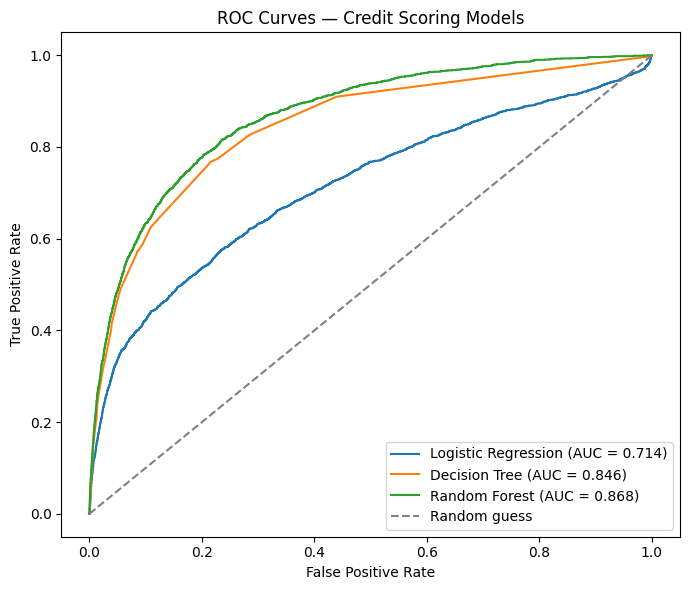

In [10]:
plt.figure(figsize=(7, 6))
for name, model, Xte in [
    ("Logistic Regression", log_reg, X_test_scaled),
    ("Decision Tree", dec_tree, X_test),
    ("Random Forest", rand_forest, X_test),
]:
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Credit Scoring Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

In [11]:
results_df = pd.DataFrame(results).set_index("Model").round(4)
print(results_df)
results_df.to_csv("model_comparison_results.csv")
results_df

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9340     0.5806  0.0449    0.0833   0.7143
Decision Tree          0.9362     0.5701  0.1865    0.2811   0.8456
Random Forest          0.9375     0.6215  0.1671    0.2634   0.8677


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9340,0.5806,0.0449,0.0833,0.7143
Decision Tree,0.9362,0.5701,0.1865,0.2811,0.8456
Random Forest,0.9375,0.6215,0.1671,0.2634,0.8677


NumberOfTimes90DaysLate                 0.296286
RevolvingUtilizationOfUnsecuredLines    0.195827
NumberOfTime60-89DaysPastDueNotWorse    0.147728
NumberOfTime30-59DaysPastDueNotWorse    0.108484
DebtRatio                               0.062672
age                                     0.056838
MonthlyIncome                           0.052506
NumberOfOpenCreditLinesAndLoans         0.042277
NumberRealEstateLoansOrLines            0.020449
NumberOfDependents                      0.016932
dtype: float64


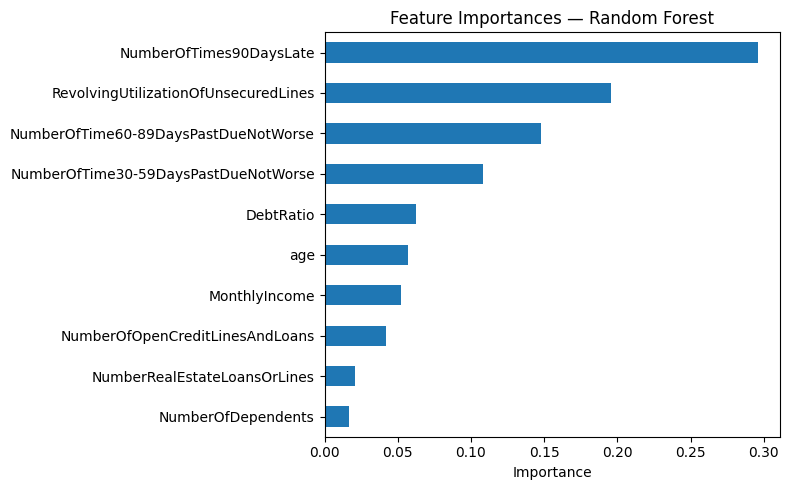

In [12]:
importances = pd.Series(rand_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [13]:
import joblib

best_row = results_df["ROC-AUC"].idxmax()
best_model = {"Logistic Regression": log_reg, "Decision Tree": dec_tree, "Random Forest": rand_forest}[best_row]

joblib.dump(best_model, "best_credit_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Best model: {best_row} (ROC-AUC = {results_df.loc[best_row, 'ROC-AUC']:.4f})")
print("Saved as 'best_credit_model.pkl'")

Best model: Random Forest (ROC-AUC = 0.8677)
Saved as 'best_credit_model.pkl'


In [14]:
from IPython.display import FileLink, display

display(FileLink("roc_curves.png"))
display(FileLink("feature_importance.png"))
display(FileLink("model_comparison_results.csv"))
display(FileLink("best_credit_model.pkl"))

/kaggle/working/roc_curves.png

/kaggle/working/feature_importance.png

/kaggle/working/model_comparison_results.csv

/kaggle/working/best_credit_model.pkl